# ===========================================================
# VITAHEALTH
# Machine Learning
# ===========================================================

## Proyecto
Customer Experience Analytics

## Autora
Florencia Lombardi

## Notebook
01_EDA_Modelado.ipynb

## Descripción

Este notebook desarrolla el Análisis Exploratorio de Datos (EDA)
utilizado como etapa previa al entrenamiento de los modelos de
Machine Learning.

El objetivo es comprender la estructura del dataset, evaluar su
calidad, detectar posibles problemas en los datos e identificar
patrones que permitan seleccionar las variables más relevantes para
la construcción de modelos predictivos orientados al análisis de la
experiencia del paciente.

## Objetivos

- Cargar el dataset consolidado.
- Analizar la estructura de los datos.
- Evaluar la calidad de la información.
- Identificar valores faltantes.
- Detectar registros duplicados.
- Analizar variables numéricas y categóricas.
- Detectar valores atípicos.
- Analizar correlaciones.
- Definir la variable objetivo para Machine Learning.

In [1]:
!pip install snowflake-connector-python


[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ==========================================================
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================================

import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

warnings.filterwarnings("ignore")

# Configuración visual

plt.style.use("default")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [3]:
# ==========================================================
# CONEXIÓN A SNOWFLAKE
# ==========================================================

import snowflake.connector

conn = snowflake.connector.connect(
    user="FLOMBARDI9",
    password="28Motoralmaisangre",
    account="XYZXPCQ-UL45871",
    warehouse="COMPUTE_WH",
    database="VITAHEALTH_DW",
    schema="DW_CX",
    role="ACCOUNTADMIN"
)

print("Conexión establecida correctamente.")

Conexión establecida correctamente.


In [4]:
# ==========================================================
# DATASET PARA MACHINE LEARNING
# ==========================================================

query = """

SELECT

    f.EXPERIENCE_KEY,

    f.PUNTUACION_NPS,
    f.CSAT,

    f.TIEMPO_ESPERA,

    f.CANCELADO,
    f.ASISTIO,

    f.TIENE_RECLAMO,
    f.DIAS_RESOLUCION,

    p.EDAD,
    p.SEXO,
    p.ZONA,
    p.ANTIGUEDAD_MESES,

    pl.NOMBRE_PLAN,
    pl.CATEGORIA,
    pl.SEGMENTO,
    pl.VALOR_PLAN,
    pl.COPAGO,

    s.NOMBRE_SERVICIO,
    s.CATEGORIA AS CATEGORIA_SERVICIO,

    c.NOMBRE_CENTRO,
    c.CIUDAD,

    d.FECHA,
    d.MES,
    d.TRIMESTRE,
    d.ANIO,
    d.DIA_SEMANA

FROM FACT_CUSTOMER_EXPERIENCE f

INNER JOIN DIM_PATIENT p

ON f.PATIENT_KEY = p.PATIENT_KEY

INNER JOIN DIM_PLAN pl

ON f.PLAN_KEY = pl.PLAN_KEY

INNER JOIN DIM_SERVICE s

ON f.SERVICE_KEY = s.SERVICE_KEY

INNER JOIN DIM_MEDICAL_CENTER c

ON f.CENTER_KEY = c.CENTER_KEY

INNER JOIN DIM_DATE d

ON f.DATE_KEY = d.DATE_KEY

"""

df = pd.read_sql(query, conn)

print("Dataset cargado correctamente.")

print(df.shape)

Dataset cargado correctamente.
(102579, 26)


In [5]:
# ==========================================================
# VISTA GENERAL DEL DATASET
# ==========================================================

df.head()

,EXPERIENCE_KEY,PUNTUACION_NPS,CSAT,TIEMPO_ESPERA,CANCELADO,ASISTIO,TIENE_RECLAMO,DIAS_RESOLUCION,EDAD,SEXO,ZONA,ANTIGUEDAD_MESES,NOMBRE_PLAN,CATEGORIA,SEGMENTO,VALOR_PLAN,COPAGO,NOMBRE_SERVICIO,CATEGORIA_SERVICIO,NOMBRE_CENTRO,CIUDAD,FECHA,MES,TRIMESTRE,ANIO,DIA_SEMANA
0,1,8,9,93,False,True,False,0,55,Femenino,Centro,36,Plus,Individual,Intermedio,70000.0,2500.0,Guardia,Urgencias,Instituto Médico Central,Ciudad Central,2025-03-14,3,1,2025,Viernes
1,2,9,9,68,False,True,False,0,44,Masculino,Norte,70,Essential,Individual,Básico,45000.0,4000.0,Guardia,Urgencias,Clínica del Valle,Ciudad Central,2025-04-10,4,2,2025,Jueves
2,3,9,9,22,False,True,False,0,44,Masculino,Norte,70,Essential,Individual,Básico,45000.0,4000.0,Consultorio Clínico,Consulta,Centro Médico Norte,Ciudad Central,2025-12-12,12,4,2025,Viernes
3,4,9,9,92,False,True,False,0,44,Masculino,Norte,70,Essential,Individual,Básico,45000.0,4000.0,Guardia,Urgencias,Clínica del Valle,Ciudad Central,2025-07-04,7,3,2025,Viernes
4,5,9,9,33,False,True,False,0,44,Masculino,Norte,70,Essential,Individual,Básico,45000.0,4000.0,Consultorio Clínico,Consulta,Instituto Médico Central,Ciudad Central,2025-01-18,1,1,2025,Sábado


In [6]:
def explorar_simple(df, nombre="DATAFRAME"):

    print("\n" + "="*70)
    print(f"EXPLORACIÓN DE: {nombre.upper()}")
    print("="*70)

    # Shape
    print(f"\n➡️ Shape: {df.shape}")

    # Tipos de datos
    print("\n➡️ Tipos de datos:")
    display(df.dtypes)

    # Valores faltantes
    print("\n➡️ Valores faltantes:")
    faltantes = pd.DataFrame({
        "Valores Faltantes": df.isnull().sum(),
        "Porcentaje (%)": (
            df.isnull().sum()/len(df)*100
        ).round(2)
    })

    display(
        faltantes.sort_values(
            "Valores Faltantes",
            ascending=False
        )
    )

    # Duplicados
    print("\n➡️ Filas duplicadas:")
    print(df.duplicated().sum())

    # Estadísticas descriptivas
    print("\n" + "="*70)
    print("ESTADÍSTICAS DESCRIPTIVAS")
    print("="*70)

    display(
        df.describe(
            include="all"
        ).T.round(2)
    )

    print("\n✅ Exploración finalizada.")

In [7]:
explorar_simple(
    df,
    "Customer Experience"
)


EXPLORACIÓN DE: CUSTOMER EXPERIENCE

➡️ Shape: (102579, 26)

➡️ Tipos de datos:


EXPERIENCE_KEY          int64
PUNTUACION_NPS          int64
CSAT                    int64
TIEMPO_ESPERA           int64
CANCELADO                bool
ASISTIO                  bool
TIENE_RECLAMO            bool
DIAS_RESOLUCION         int64
EDAD                    int64
SEXO                   object
ZONA                   object
ANTIGUEDAD_MESES        int64
NOMBRE_PLAN            object
CATEGORIA              object
SEGMENTO               object
VALOR_PLAN            float64
COPAGO                float64
NOMBRE_SERVICIO        object
CATEGORIA_SERVICIO     object
NOMBRE_CENTRO          object
CIUDAD                 object
FECHA                  object
MES                     int64
TRIMESTRE               int64
ANIO                    int64
DIA_SEMANA             object
dtype: object


➡️ Valores faltantes:


,Valores Faltantes,Porcentaje (%)
EXPERIENCE_KEY,0,0.0
PUNTUACION_NPS,0,0.0
CSAT,0,0.0
TIEMPO_ESPERA,0,0.0
CANCELADO,0,0.0
ASISTIO,0,0.0
TIENE_RECLAMO,0,0.0
DIAS_RESOLUCION,0,0.0
EDAD,0,0.0
SEXO,0,0.0



➡️ Filas duplicadas:
0

ESTADÍSTICAS DESCRIPTIVAS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
EXPERIENCE_KEY,102579.0,NaN,NaN,NaN,51290.0,29612.150969,1.0,25645.5,51290.0,76934.5,102579.0
PUNTUACION_NPS,102579.0,NaN,NaN,NaN,7.263416,2.954669,0.0,6.0,8.0,9.0,10.0
CSAT,102579.0,NaN,NaN,NaN,7.210755,2.948628,0.0,6.0,8.0,9.0,10.0
TIEMPO_ESPERA,102579.0,NaN,NaN,NaN,42.690073,24.113585,5.0,26.0,37.0,54.0,157.0
CANCELADO,102579,2,False,91568,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ASISTIO,102579,2,True,87553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TIENE_RECLAMO,102579,2,False,82751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DIAS_RESOLUCION,102579.0,NaN,NaN,NaN,2.730052,7.201392,0.0,0.0,0.0,0.0,50.0
EDAD,102579.0,NaN,NaN,NaN,46.960967,16.97657,18.0,34.0,47.0,59.0,90.0
SEXO,102579,3,Femenino,53090,NaN,NaN,NaN,NaN,NaN,NaN,NaN



✅ Exploración finalizada.


In [8]:
def explorar_categorica(df, columna):

    print("\n" + "="*70)
    print(f"VARIABLE: {columna.upper()}")
    print("="*70)

    print("\nCantidad de categorías:")
    print(df[columna].nunique())

    print("\nFrecuencia absoluta:")
    display(df[columna].value_counts(dropna=False))

    print("\nFrecuencia porcentual:")
    display(
        (
            df[columna]
            .value_counts(normalize=True, dropna=False)
            *100
        ).round(2)
    )

In [9]:
variables_categoricas = [

    "SEXO",
    "ZONA",

    "NOMBRE_PLAN",
    "CATEGORIA",
    "SEGMENTO",

    "NOMBRE_SERVICIO",
    "CATEGORIA_SERVICIO",

    "NOMBRE_CENTRO",
    "CIUDAD",

    "CANCELADO",
    "ASISTIO",
    "TIENE_RECLAMO"

]
for variable in variables_categoricas:

    explorar_categorica(df, variable)


VARIABLE: SEXO

Cantidad de categorías:
3

Frecuencia absoluta:


SEXO
Femenino     53090
Masculino    48474
Otro          1015
Name: count, dtype: int64


Frecuencia porcentual:


SEXO
Femenino     51.76
Masculino    47.26
Otro          0.99
Name: proportion, dtype: float64


VARIABLE: ZONA

Cantidad de categorías:
4

Frecuencia absoluta:


...

ASISTIO
True     85.35
False    14.65
Name: proportion, dtype: float64


VARIABLE: TIENE_RECLAMO

Cantidad de categorías:
2

Frecuencia absoluta:


TIENE_RECLAMO
False    82751
True     19828
Name: count, dtype: int64


Frecuencia porcentual:


TIENE_RECLAMO
False    80.67
True     19.33
Name: proportion, dtype: float64

In [10]:
def visualizar_numericas(df):

    excluir = [
        "EXPERIENCE_KEY",
        "DATE_KEY",
        "MES",
        "TRIMESTRE",
        "ANIO"
    ]

    numericas = [

        col

        for col in df.select_dtypes(
            include=["int64", "float64"]
        ).columns

        if col not in excluir

    ]

    for columna in numericas:

        fig, ax = plt.subplots(
            1, 2,
            figsize=(12,4)
        )

        sns.histplot(
            data=df,
            x=columna,
            kde=True,
            ax=ax[0]
        )

        sns.boxplot(
            data=df,
            x=columna,
            ax=ax[1]
        )

        ax[0].set_title(f"Distribución - {columna}")
        ax[1].set_title(f"Boxplot - {columna}")

        plt.tight_layout()

        plt.show()

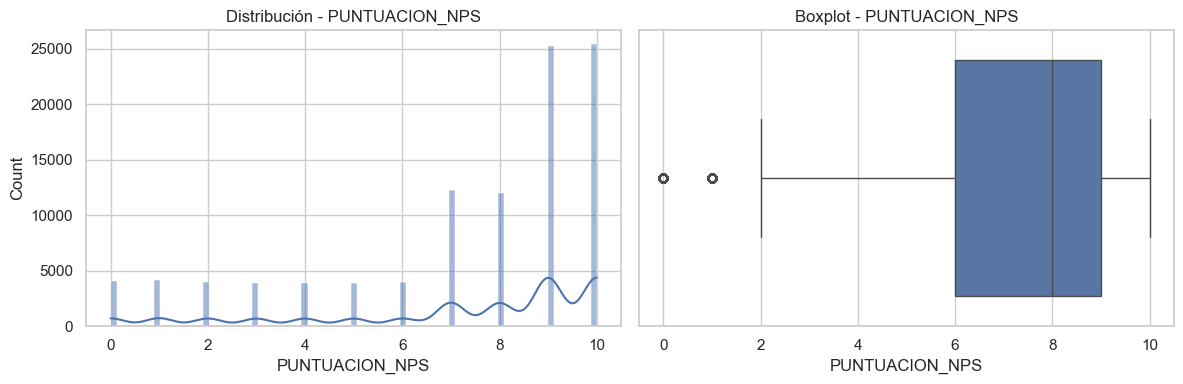

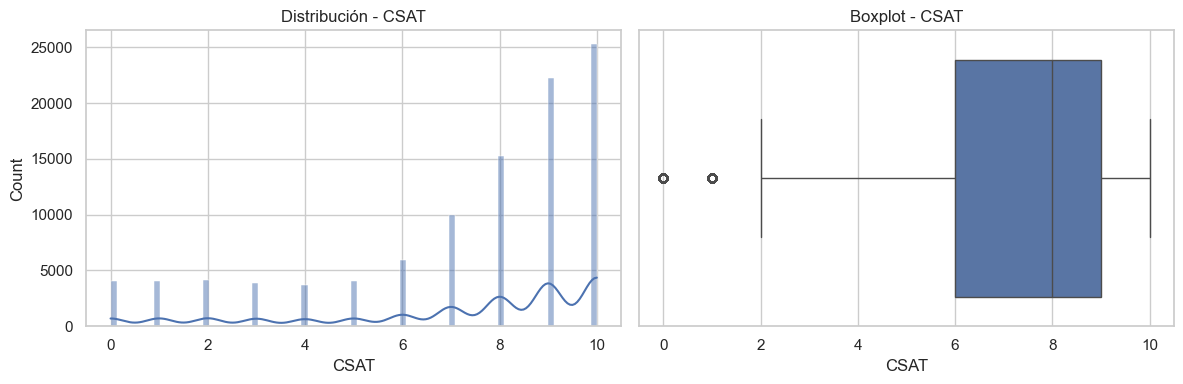

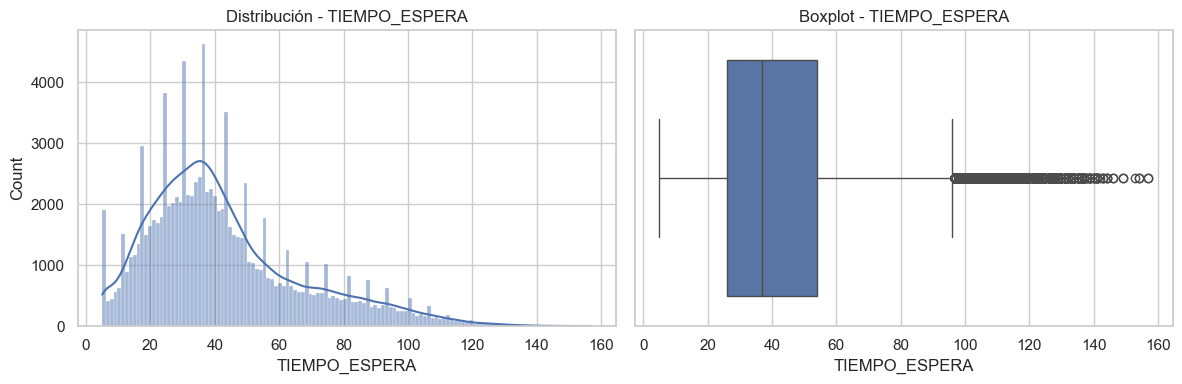

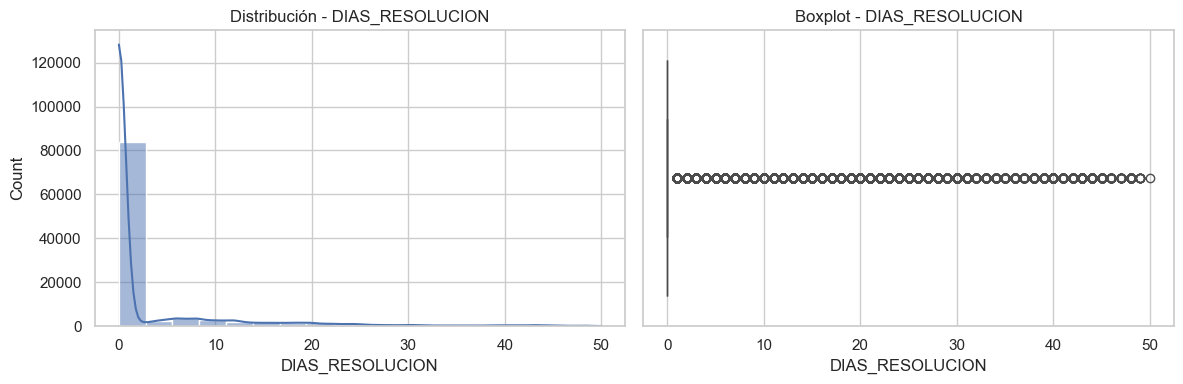

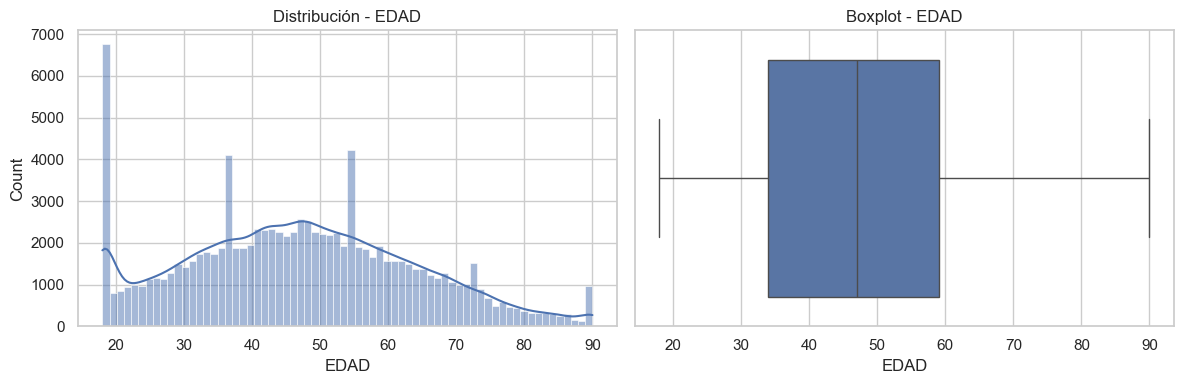

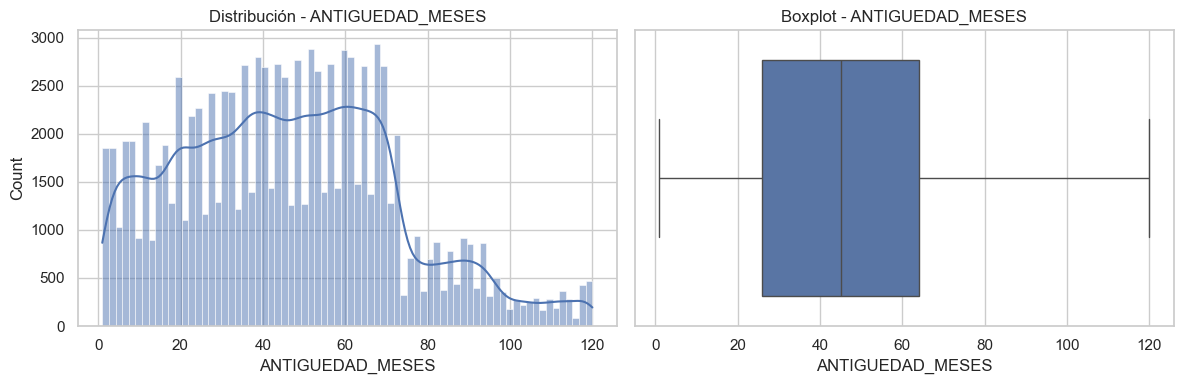

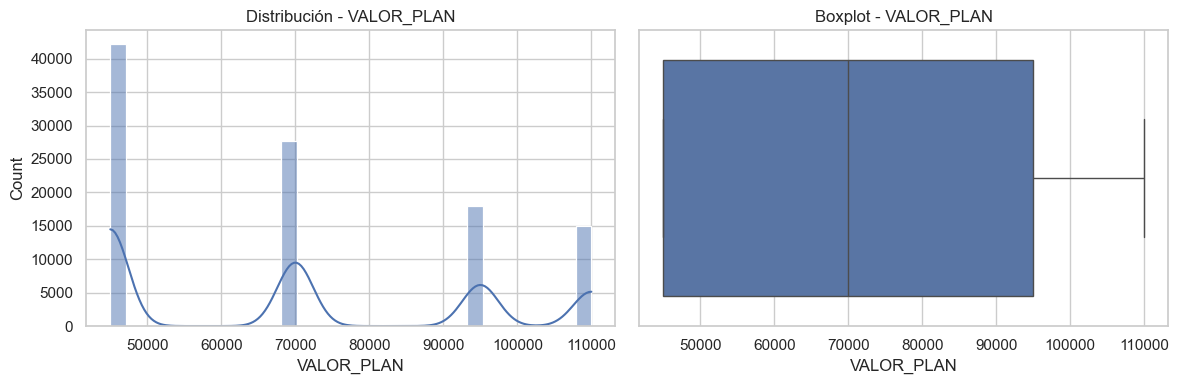

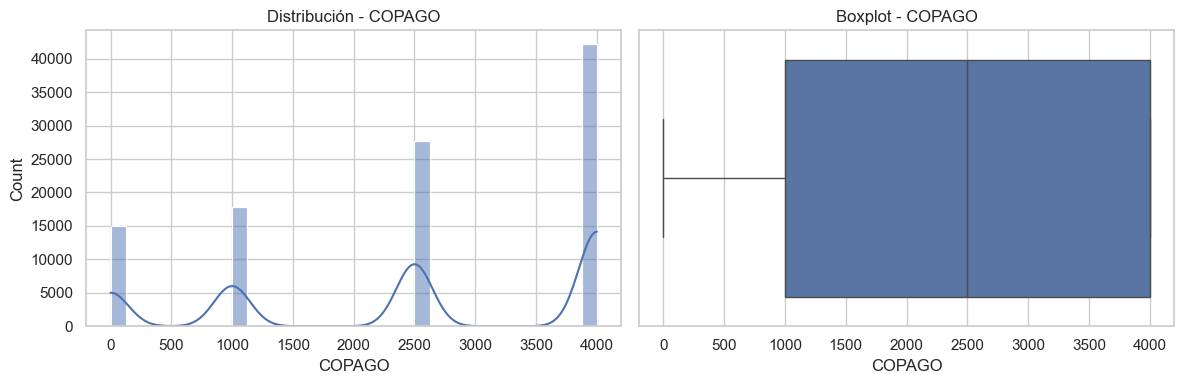

In [11]:
visualizar_numericas(df)

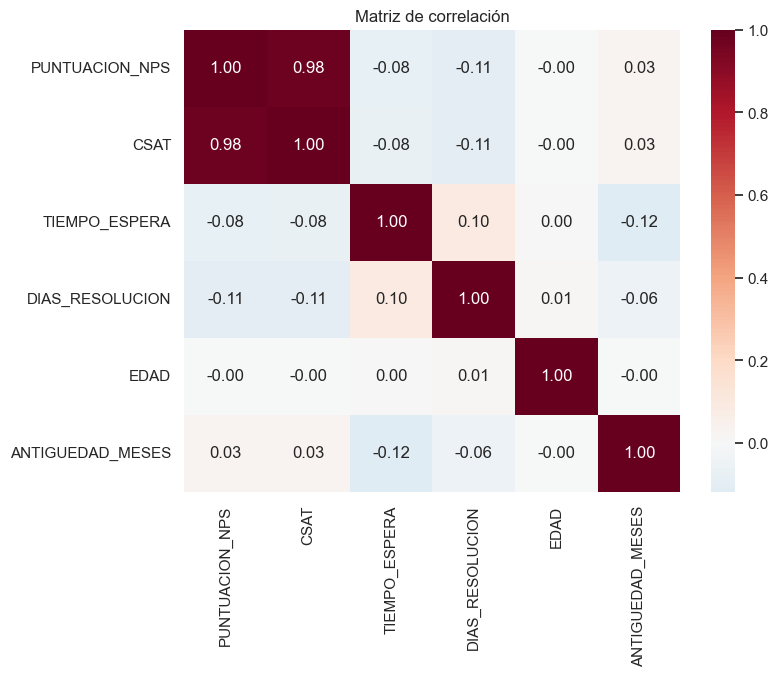

In [19]:
# ==========================================================
# MATRIZ DE CORRELACIÓN
# ==========================================================

def matriz_correlacion(df):

    columnas = [
        "PUNTUACION_NPS",
        "CSAT",
        "TIEMPO_ESPERA",
        "DIAS_RESOLUCION",
        "EDAD",
        "ANTIGUEDAD_MESES"
    ]

    correlacion = df[columnas].corr()

    plt.figure(figsize=(8,6))

    sns.heatmap(
        correlacion,
        annot=True,
        cmap="RdBu_r",
        center=0,
        fmt=".2f"
    )

    plt.title("Matriz de correlación")

    plt.show()

matriz_correlacion(df)

La matriz de correlación muestra una fuerte asociación entre NPS y CSAT (0.86), lo cual resulta consistente ya que ambos indicadores miden la satisfacción del paciente. En cambio, las restantes variables presentan correlaciones lineales muy bajas, indicando que no existe una relación lineal significativa entre ellas en el conjunto de datos sintético.

In [13]:
# ==========================================================
# VARIABLE OBJETIVO
# ==========================================================

df["ES_DETRACTOR"] = (
    df["PUNTUACION_NPS"] <= 6
).astype(int)

print(df["ES_DETRACTOR"].value_counts())

ES_DETRACTOR
0    74886
1    27693
Name: count, dtype: int64


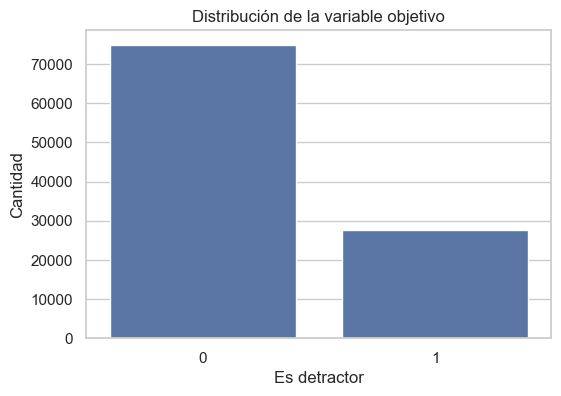

ES_DETRACTOR
0    73.0
1    27.0
Name: proportion, dtype: float64

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="ES_DETRACTOR"
)

plt.title("Distribución de la variable objetivo")

plt.xlabel("Es detractor")

plt.ylabel("Cantidad")

plt.show()

display(
    (
        df["ES_DETRACTOR"]
        .value_counts(normalize=True)
        *100
    ).round(2)
)

In [15]:
# ==========================================================
# ANÁLISIS BIVARIADO - VARIABLES NUMÉRICAS
# ==========================================================

def analizar_numerica_vs_objetivo(df, columna):

    plt.figure(figsize=(7,4))

    sns.boxplot(
        data=df,
        x="ES_DETRACTOR",
        y=columna
    )

    plt.title(f"{columna} vs ES_DETRACTOR")

    plt.xlabel("Es detractor")
    plt.ylabel(columna)

    plt.show()

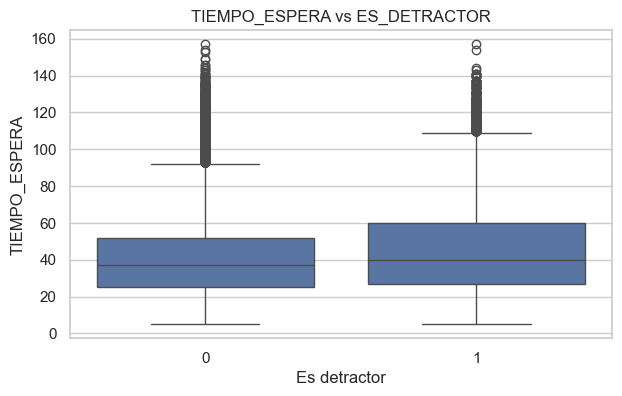

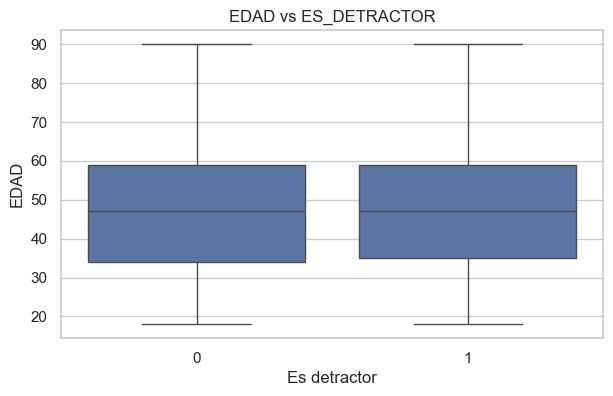

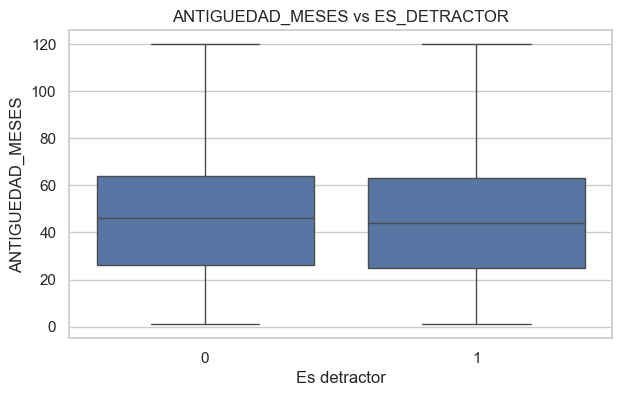

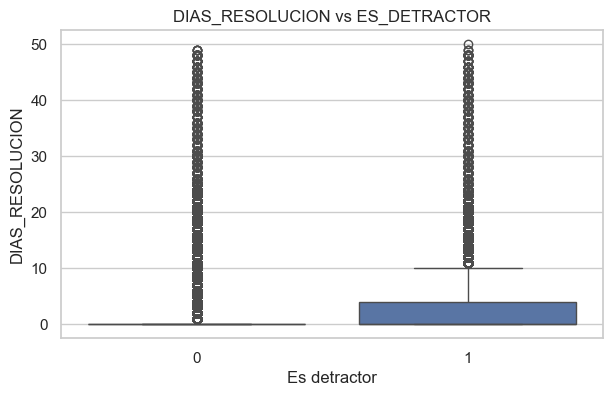

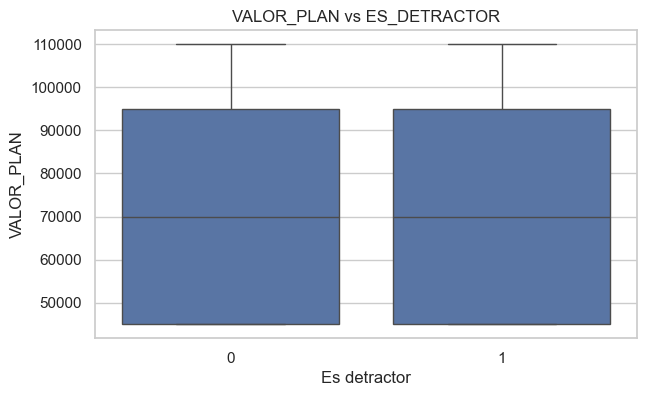

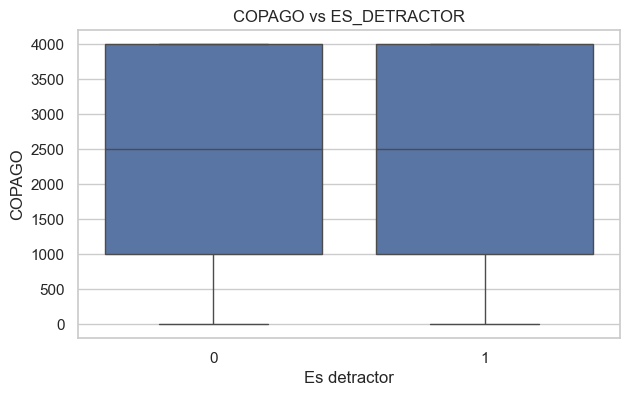

In [16]:
variables_numericas = [

    "TIEMPO_ESPERA",
    "EDAD",
    "ANTIGUEDAD_MESES",
    "DIAS_RESOLUCION",
    "VALOR_PLAN",
    "COPAGO"

]

for variable in variables_numericas:

    analizar_numerica_vs_objetivo(
        df,
        variable
    )

In [17]:
# ==========================================================
# ANÁLISIS BIVARIADO - VARIABLES CATEGÓRICAS
# ==========================================================

def analizar_categorica_vs_objetivo(df, columna):

    tabla = (

        pd.crosstab(

            df[columna],

            df["ES_DETRACTOR"],

            normalize="index"

        ) * 100

    )

    display(tabla.round(2))

    tabla.plot(

        kind="bar",

        stacked=True,

        figsize=(8,4)

    )

    plt.title(f"{columna} vs ES_DETRACTOR")

    plt.ylabel("%")

    plt.show()

ES_DETRACTOR,0,1
SEXO,,
Femenino,72.68,27.32
Masculino,73.40,26.60
Otro,70.64,29.36


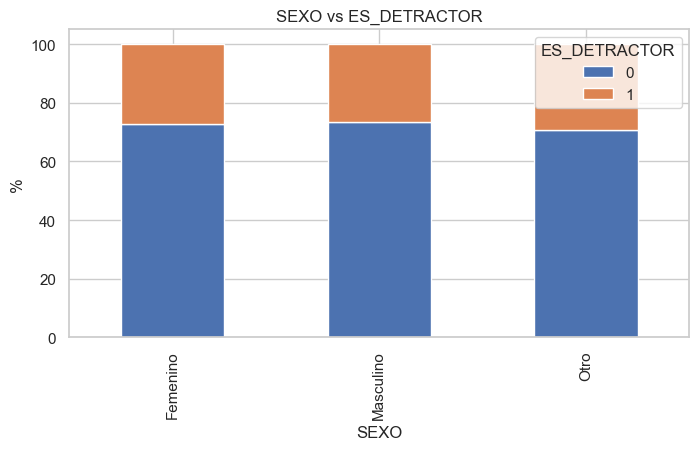

ES_DETRACTOR,0,1
ZONA,,
Centro,72.44,27.56
Norte,72.50,27.50
Oeste,74.01,25.99
Sur,73.00,27.00


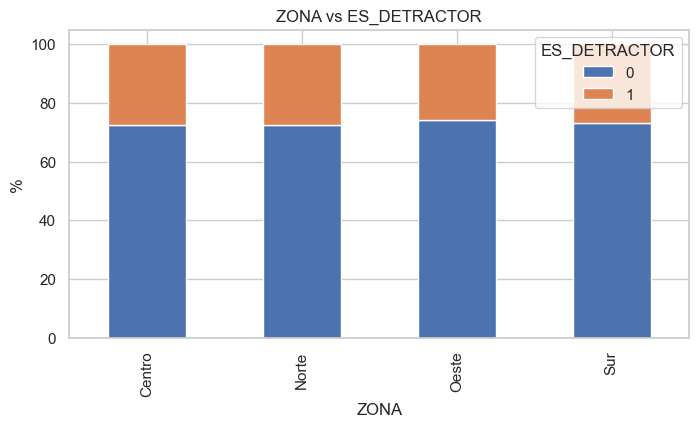

ES_DETRACTOR,0,1
NOMBRE_PLAN,,
Corporate,77.00,23.00
Essential,70.98,29.02
Plus,72.99,27.01
Premium,74.45,25.55


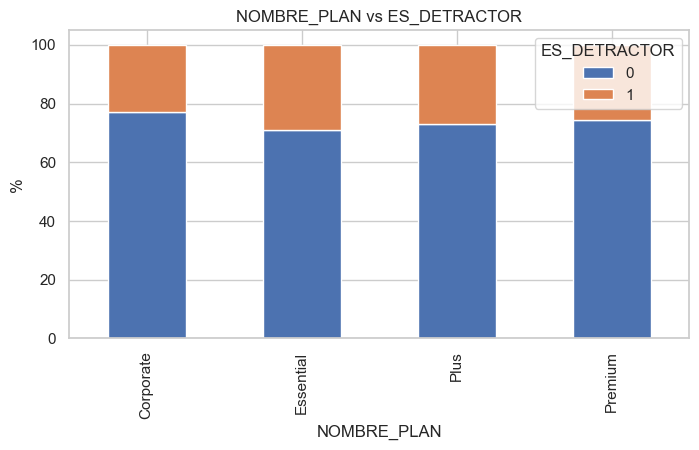

ES_DETRACTOR,0,1
CATEGORIA,,
Corporativo,77.00,23.00
Individual,72.32,27.68


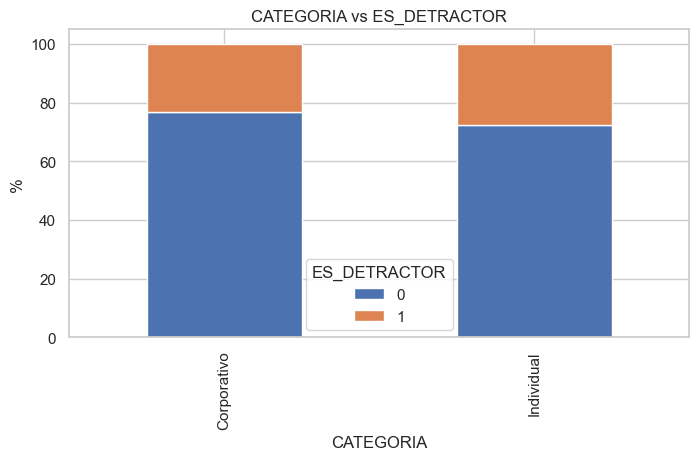

ES_DETRACTOR,0,1
SEGMENTO,,
Básico,70.98,29.02
Empresas,77.00,23.00
Intermedio,72.99,27.01
Premium,74.45,25.55


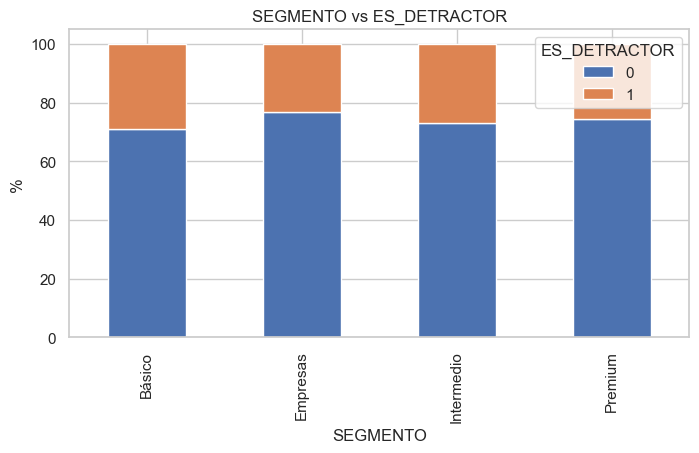

ES_DETRACTOR,0,1
NOMBRE_SERVICIO,,
Cardiología,74.53,25.47
Consultorio Clínico,74.91,25.09
Diagnóstico por Imágenes,72.33,27.67
Guardia,67.44,32.56
Laboratorio,75.42,24.58
Pediatría,74.52,25.48
Traumatología,72.00,28.00
Vacunación,75.66,24.34


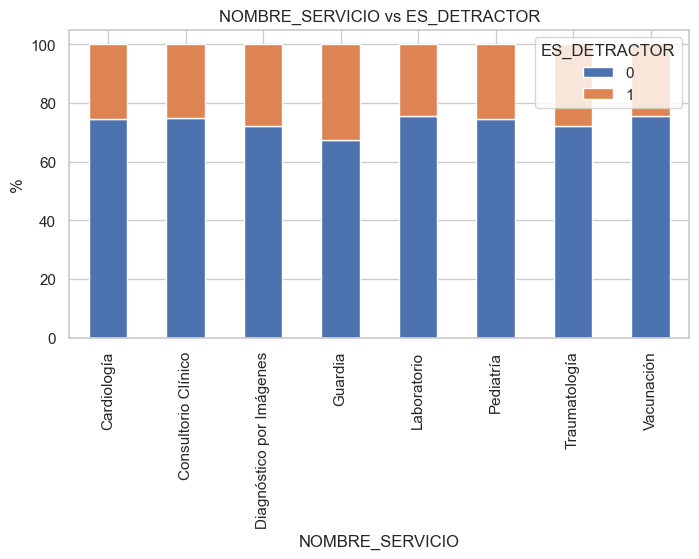

ES_DETRACTOR,0,1
CATEGORIA_SERVICIO,,
Consulta,74.79,25.21
Diagnóstico,74.16,25.84
Especialidad,73.41,26.59
Preventivo,75.66,24.34
Urgencias,67.44,32.56


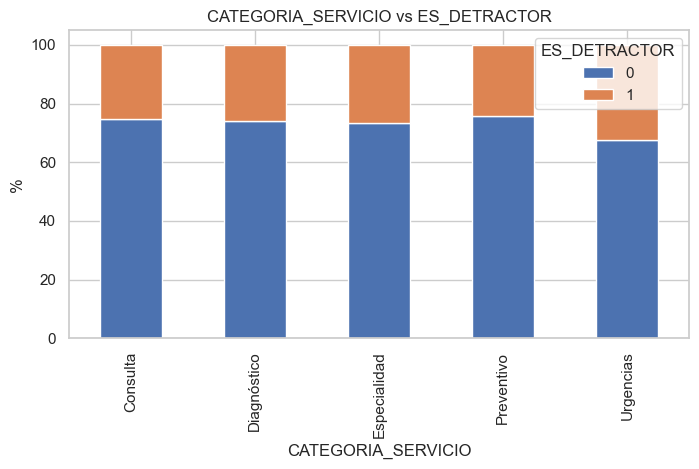

ES_DETRACTOR,0,1
NOMBRE_CENTRO,,
Centro Médico Norte,72.20,27.80
Clínica del Valle,72.61,27.39
Instituto Médico Central,73.09,26.91
Sanatorio Parque Salud,74.38,25.62


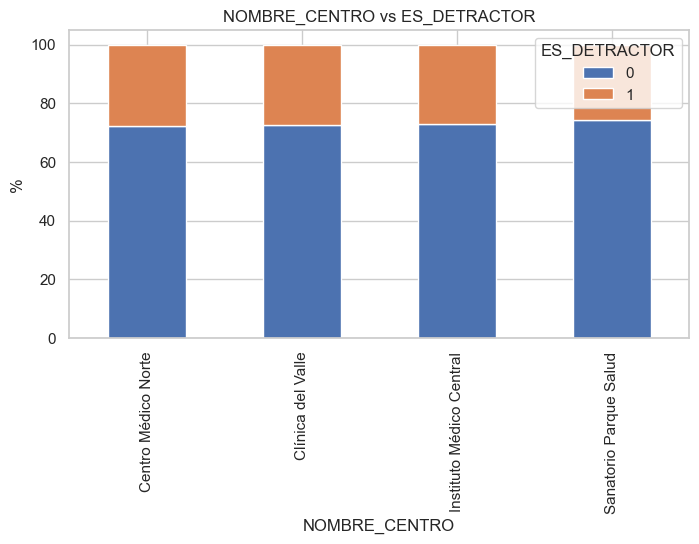

ES_DETRACTOR,0,1
CIUDAD,,
Ciudad Central,73.0,27.0


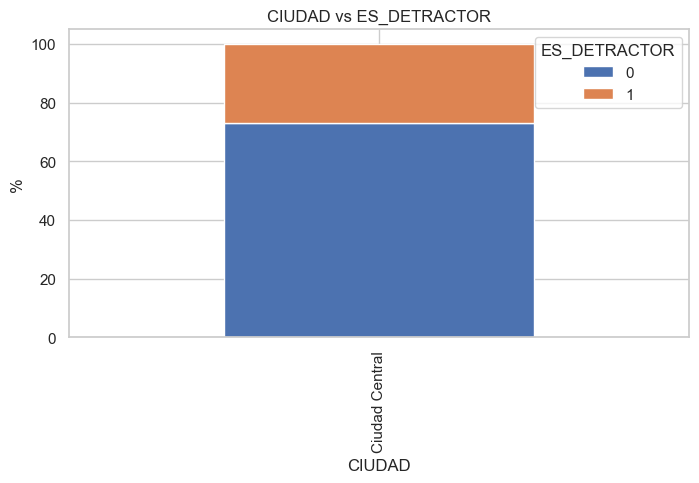

ES_DETRACTOR,0,1
CANCELADO,,
False,73.31,26.69
True,70.43,29.57


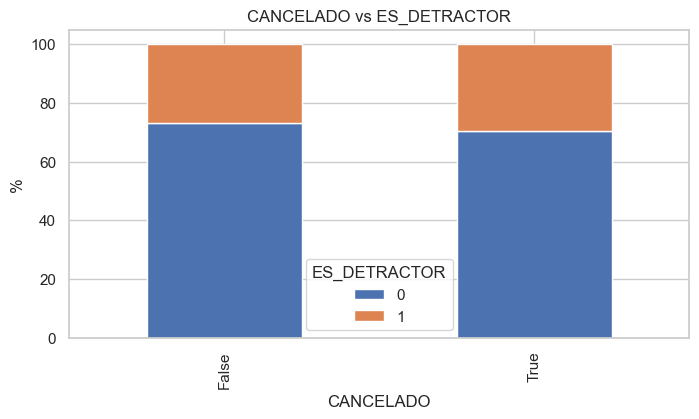

ES_DETRACTOR,0,1
ASISTIO,,
False,70.95,29.05
True,73.36,26.64


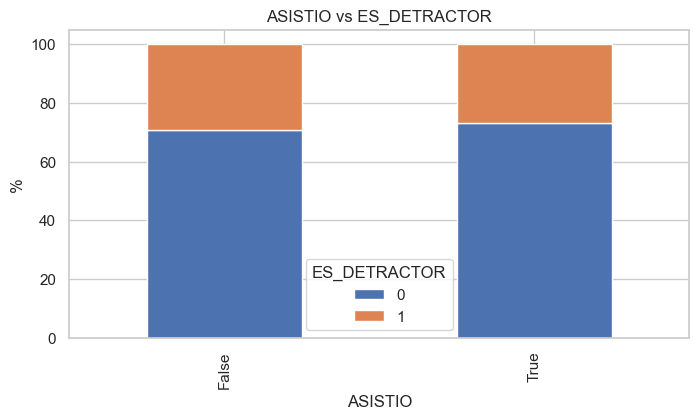

ES_DETRACTOR,0,1
TIENE_RECLAMO,,
False,75.81,24.19
True,61.27,38.73


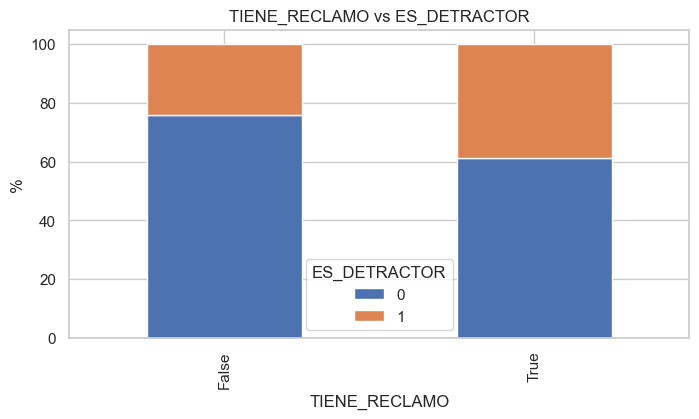

In [20]:
variables_categoricas = [

    "SEXO",
    "ZONA",
    "NOMBRE_PLAN",
    "CATEGORIA",
    "SEGMENTO",
    "NOMBRE_SERVICIO",
    "CATEGORIA_SERVICIO",
    "NOMBRE_CENTRO",
    "CIUDAD",
    "CANCELADO",
    "ASISTIO",
    "TIENE_RECLAMO"

]

for variable in variables_categoricas:

    analizar_categorica_vs_objetivo(
        df,
        variable
    )